In [ ]:
import requests
import json
import pandas as pd
from datetime import datetime, timedelta
import random

In [ ]:
df = pd.read_csv('df_final.csv')

In [ ]:
# Diccionario provincias
coords = {
    "Ávila": (40.6565, -4.6818),
    "Burgos": (42.3439, -3.6969),
    "León": (42.5987, -5.5671),
    "Salamanca": (40.9701, -5.6635),
    "Segovia": (40.9429, -4.1088),
    "Soria": (41.7636, -2.4649),
    "Valladolid": (41.6523, -4.7245),
    "Zamora": (41.5033, -5.7446)
}

In [ ]:
def pacientes_ayer_random():
  return random.randint(11, 380)

def get_data(coords, provincia):
  # Obtener coordenadas automáticamente
  lat, lon = coords[provincia]

  # URL Open-Meteo
  url = (
      "https://api.open-meteo.com/v1/forecast"
      f"?latitude={lat}"
      f"&longitude={lon}"
      "&hourly="
      "temperature_2m,"
      "relative_humidity_2m,"
      "wind_speed_10m,"
      "precipitation"
      "&forecast_days=2"
  )

  # Petición API
  response = requests.get(url)

  # JSON
  data = response.json()

  # DataFrame
  df_weather = pd.DataFrame({
      "fecha_hora": data["hourly"]["time"],
      "temperatura": data["hourly"]["temperature_2m"],
      "humedad": data["hourly"]["relative_humidity_2m"],
      "viento": data["hourly"]["wind_speed_10m"],
      "precipitacion": data["hourly"]["precipitation"]
  })

  # Convertir fecha
  df_weather["fecha_hora"] = pd.to_datetime(df_weather["fecha_hora"])

  # Obtener mañana
  mañana = (datetime.now() + timedelta(days=1)).date()

  # Filtrar mañana
  df_mañana = df_weather[
      df_weather["fecha_hora"].dt.date == mañana
  ]

  # Resumen meteorológico
  resultado = {
      "provincia": provincia,
      "temperatura_media": round(df_mañana["temperatura"].mean(), 2),
      "temperatura_maxima": df_mañana["temperatura"].max(),
      "temperatura_minima": df_mañana["temperatura"].min(),
      "viento_medio": round(df_mañana["viento"].mean(), 2),
      "viento_maximo": df_mañana["viento"].max(),
      "humedad_media": round(df_mañana["humedad"].mean(), 2),
      "precipitaciones": round(df_mañana["precipitacion"].sum(), 2),
      "fecha_mañana": mañana
  }

  return pd.DataFrame({k: [v] for k, v in resultado.items()})

In [ ]:
get_data(coords, "Burgos")

,provincia,temperatura_media,temperatura_maxima,temperatura_minima,viento_medio,viento_maximo,humedad_media,precipitaciones,fecha_mañana
0,Burgos,16.82,22.5,12.2,14.65,22.2,61.83,0.0,2026-06-02


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [ ]:
# copias del dataset original para probar los modelos
df_prophet = df.copy()
df_sarimax = df.copy()

In [ ]:
df_prophet = df_prophet.rename(columns={'fecha': 'ds', 'target_pacientes': 'y'})
df_sarimax = df_sarimax.rename(columns={'fecha': 'ds', 'target_pacientes': 'y'})

In [ ]:
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_sarimax['ds'] = pd.to_datetime(df_sarimax['ds'])

In [ ]:
mapeo_provincia = {
    "Burgos": 0,
    "León": 1,
    "Salamanca": 2,
    "Segovia": 3,
    "Soria": 4,
    "Valladolid": 5,
    "Zamora": 6,
    "Ávila": 7
}
mapeo_dia_semana = {
    "LUNES": 0,
    "MARTES": 1,
    "MIÉRCOLES": 2,
    "JUEVES": 3,
    "VIERNES": 4,
    "SÁBADO": 5,
    "DOMINGO": 6
}


df_prophet["provincia"] = df_prophet["provincia"].map(mapeo_provincia)
df_prophet["dia_semana"] = df_prophet["dia_semana"].map(mapeo_dia_semana)
df_sarimax["provincia"] = df_sarimax["provincia"].map(mapeo_provincia)
df_sarimax["dia_semana"] = df_sarimax["dia_semana"].map(mapeo_dia_semana)

PROPHET

POR SENCILLEZ VAMOS A COGER SOLO LAS PROVINCIAS QUE TENGAN UN HOSPITAL PARA EVITAR REPETIR FECHAS EN PROPHET

In [ ]:
df_prophet[df_prophet["provincia"] == 2]["hospital"].unique()

array(['C.A.U. Salamanca'], dtype=object)

In [ ]:
df_prophet[df_prophet["provincia"] == 3]["hospital"].unique()

array(['C.A. Segovia'], dtype=object)

In [ ]:
df_prophet

,ds,hospital,provincia,dia_semana,mes,year,pacientes_ayer,temperatura_media,temperatura_maxima,temperatura_minima,viento,viento_maximo,precipitaciones,humedad,y
0,2024-01-01,C.A.U. Burgos,0,LUNES,1,2024,133,3.3,6.5,1.0,17.0,27.8,1.27,84.0,133
1,2024-01-02,C.A.U. Burgos,0,MARTES,1,2024,133,7.0,10.1,4.0,32.0,42.4,0.00,82.0,189
2,2024-01-03,C.A.U. Burgos,0,MIÉRCOLES,1,2024,189,9.3,11.6,7.0,24.1,33.5,1.52,91.0,153
3,2024-01-04,C.A.U. Burgos,0,JUEVES,1,2024,153,6.8,9.6,5.0,16.7,27.8,1.52,86.0,149
4,2024-01-05,C.A.U. Burgos,0,VIERNES,1,2024,149,3.3,7.0,0.0,7.0,18.3,0.76,88.0,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7881,2025-08-27,C.A. Ávila,7,MIÉRCOLES,8,2025,96,0.0,0.0,0.0,0.0,0.0,0.00,0.0,109
7882,2025-08-28,C.A. Ávila,7,JUEVES,8,2025,109,0.0,0.0,0.0,0.0,0.0,0.00,0.0,113
7883,2025-08-29,C.A. Ávila,7,VIERNES,8,2025,113,0.0,0.0,0.0,0.0,0.0,0.00,0.0,81
7884,2025-08-30,C.A. Ávila,7,SÁBADO,8,2025,81,0.0,0.0,0.0,0.0,0.0,0.00,0.0,80


In [ ]:
#Convertir automáticamente columnas categóricas
for col in df_prophet.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_prophet[col] = le.fit_transform(df_prophet[col].astype(str))

In [ ]:
df_propeht_salamanca = df_prophet[df_prophet["hospital"] == 2]
df_propeht_segovia = df_prophet[df_prophet["hospital"] == 3]

In [ ]:
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7886 entries, 0 to 7885
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ds                  7886 non-null   datetime64[ns]
 1   hospital            7886 non-null   int64         
 2   provincia           7886 non-null   int64         
 3   dia_semana          7886 non-null   int64         
 4   mes                 7886 non-null   int64         
 5   year                7886 non-null   int64         
 6   pacientes_ayer      7886 non-null   int64         
 7   temperatura_media   7886 non-null   float64       
 8   temperatura_maxima  7886 non-null   float64       
 9   temperatura_minima  7886 non-null   float64       
 10  viento              7886 non-null   float64       
 11  viento_maximo       7886 non-null   float64       
 12  precipitaciones     7886 non-null   float64       
 13  humedad             7886 non-null   float64     

In [ ]:
# Train y test salamanca
fecha_corte = df_propeht_salamanca['ds'].max() - pd.Timedelta(days=30)
train_salamanca = df_propeht_salamanca[df_propeht_salamanca['ds'] <= fecha_corte].copy()
test_salamanca = df_propeht_salamanca[df_propeht_salamanca['ds'] > fecha_corte].copy()

# Train y test segovia
fecha_corte = df_propeht_segovia['ds'].max() - pd.Timedelta(days=30)
train_segovia = df_propeht_segovia[df_propeht_segovia['ds'] <= fecha_corte].copy()
test_segovia = df_propeht_segovia[df_propeht_segovia['ds'] > fecha_corte].copy()

In [ ]:
model_salamanca = Prophet(
    yearly_seasonality=True,  # Activa si los datos cambian según la época del año
    weekly_seasonality=True,  # Activa si cambian según el día de la semana (ej. laborables vs findes)
    daily_seasonality=False   # Solo True si los datos tienen registros por horas
)

model_segovia = Prophet(
    yearly_seasonality=True,  # Activa si los datos cambian según la época del año
    weekly_seasonality=True,  # Activa si cambian según el día de la semana (ej. laborables vs findes)
    daily_seasonality=False   # Solo True si los datos tienen registros por horas
)

In [ ]:
# Añadimos variables climatologicas al modelo
model_salamanca.add_regressor('hospital')
model_salamanca.add_regressor('provincia')
model_salamanca.add_regressor('pacientes_ayer')
model_salamanca.add_regressor('dia_semana')
model_salamanca.add_regressor('mes')
model_salamanca.add_regressor('year')
model_salamanca.add_regressor('temperatura_media')
model_salamanca.add_regressor('temperatura_maxima')
model_salamanca.add_regressor('temperatura_minima')
model_salamanca.add_regressor('viento')
model_salamanca.add_regressor('viento_maximo')
model_salamanca.add_regressor('humedad')
model_salamanca.add_regressor('precipitaciones')

model_segovia.add_regressor('hospital')
model_segovia.add_regressor('provincia')
model_segovia.add_regressor('pacientes_ayer')
model_segovia.add_regressor('dia_semana')
model_segovia.add_regressor('mes')
model_segovia.add_regressor('year')
model_segovia.add_regressor('temperatura_media')
model_segovia.add_regressor('temperatura_maxima')
model_segovia.add_regressor('temperatura_minima')
model_segovia.add_regressor('viento')
model_segovia.add_regressor('viento_maximo')
model_segovia.add_regressor('humedad')
model_segovia.add_regressor('precipitaciones')

In [ ]:
model_salamanca.fit(train_salamanca)
model_segovia.fit(train_segovia)

In [ ]:
columnas_futuro = [
    'ds',
    'hospital',
    'provincia',
    'pacientes_ayer',
    'dia_semana',
    'mes',
    'year',
    'temperatura_media',
    'temperatura_maxima',
    'temperatura_minima',
    'viento',
    'viento_maximo',
    'humedad',
    'precipitaciones'
]

future_salamanca = test_salamanca[columnas_futuro].copy()

future_segovia = test_segovia[columnas_futuro].copy()

In [ ]:
forecast_salamanca = model_salamanca.predict(future_salamanca)

print("--- PRIMERAS PREDICCIONES GENERADAS PARA SALAMANCA---")
print(forecast_salamanca[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

--- PRIMERAS PREDICCIONES GENERADAS PARA SALAMANCA---
          ds        yhat  yhat_lower  yhat_upper
0 2025-08-02   94.518866   81.715973  106.816697
1 2025-08-03   95.830717   82.640929  108.518145
2 2025-08-04  116.840983  105.197030  129.033084
3 2025-08-05  111.781879   99.143336  124.773522
4 2025-08-06  106.224019   92.694495  119.093442


In [ ]:
forecast_segovia = model_segovia.predict(future_segovia)

print("--- PRIMERAS PREDICCIONES GENERADAS PARA SEGOVIA---")
print(forecast_segovia[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

--- PRIMERAS PREDICCIONES GENERADAS PARA SEGOVIA---
          ds        yhat  yhat_lower  yhat_upper
0 2025-08-02   92.092238   78.843489  105.646848
1 2025-08-03   93.484738   80.197114  106.680250
2 2025-08-04  110.798536   97.336989  123.805614
3 2025-08-05  110.742597   98.054528  123.661086
4 2025-08-06  109.041218   95.929173  121.165260


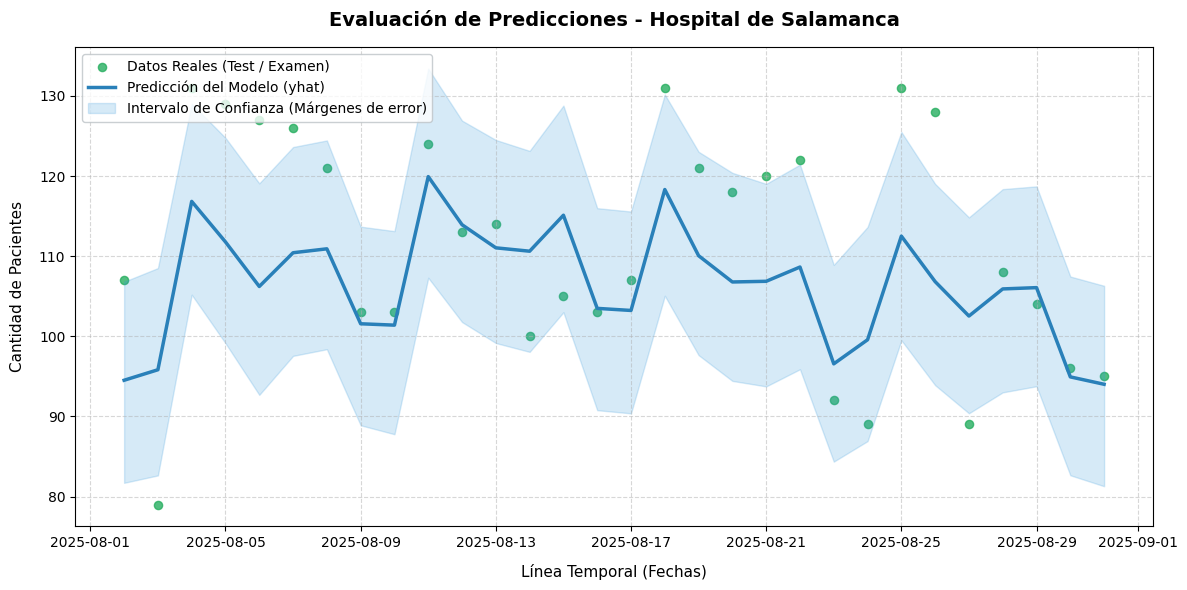

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(test_salamanca['ds'], test_salamanca['y'],
            color='#27ae60', s=35, alpha=0.8, label='Datos Reales (Test / Examen)')

plt.plot(forecast_salamanca['ds'], forecast_salamanca['yhat'],
         color='#2980b9', linewidth=2.5, label='Predicción del Modelo (yhat)')

plt.fill_between(forecast_salamanca['ds'],
                 forecast_salamanca['yhat_lower'],
                 forecast_salamanca['yhat_upper'],
                 color='#3498db', alpha=0.2, label='Intervalo de Confianza (Márgenes de error)')

plt.title("Evaluación de Predicciones - Hospital de Salamanca", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Línea Temporal (Fechas)", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Pacientes", fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#bdc3c7')

plt.tight_layout()
plt.show()

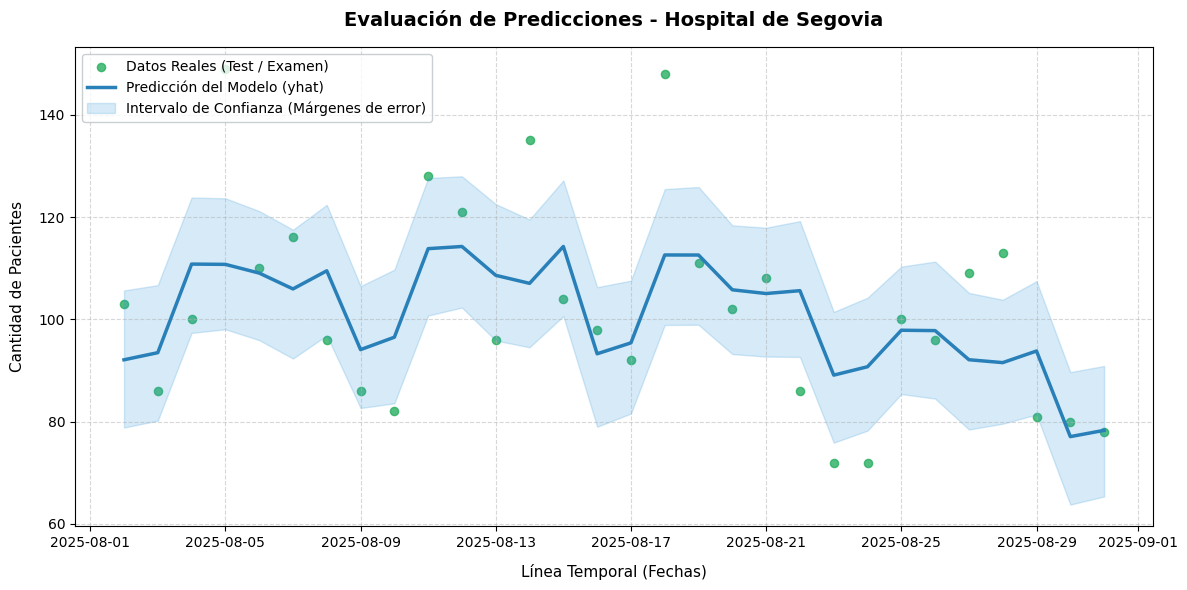

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(test_segovia['ds'], test_segovia['y'],
            color='#27ae60', s=35, alpha=0.8, label='Datos Reales (Test / Examen)')

plt.plot(forecast_segovia['ds'], forecast_segovia['yhat'],
         color='#2980b9', linewidth=2.5, label='Predicción del Modelo (yhat)')

plt.fill_between(forecast_segovia['ds'],
                 forecast_segovia['yhat_lower'],
                 forecast_segovia['yhat_upper'],
                 color='#3498db', alpha=0.2, label='Intervalo de Confianza (Márgenes de error)')

plt.title("Evaluación de Predicciones - Hospital de Segovia", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Línea Temporal (Fechas)", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Pacientes", fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#bdc3c7')

plt.tight_layout()
plt.show()

In [ ]:
tabla_comparativa = forecast_salamanca[['yhat']].copy().rename(columns={'yhat': 'yhat_prophet_salamanca'})
tabla_comparativa['y_real_prophet_salamanca'] = test_salamanca['y'].values

tabla_comparativa['error_absoluto_prophet_salamanca'] = (tabla_comparativa['y_real_prophet_salamanca'] - tabla_comparativa['yhat_prophet_salamanca']).abs()

print("--- COMPARATIVA DE PREDICCIONES PARA SALAMANCA ---")
columnas_ordenadas = ['y_real_prophet_salamanca', 'yhat_prophet_salamanca', 'error_absoluto_prophet_salamanca']
print(tabla_comparativa[columnas_ordenadas].head())

error_medio = tabla_comparativa['error_absoluto_prophet_salamanca'].mean()

print("\n--- NOTA FINAL DEL MODELO ---")
print(f"De media, el modelo de Salamanca se equivoca en: {error_medio:.2f} pacientes por día.")

--- COMPARATIVA DE PREDICCIONES PARA SALAMANCA ---
   y_real_salamanca  yhat_salamanca  error_absoluto_salamanca
0               107       94.518866                 12.481134
1                79       95.830717                 16.830717
2               131      116.840983                 14.159017
3               129      111.781879                 17.218121
4               127      106.224019                 20.775981

--- NOTA FINAL DEL MODELO ---
De media, el modelo de Salamanca se equivoca en: 9.30 pacientes por día.


In [ ]:
tabla_comparativa['yhat_prophet_segovia'] = forecast_segovia[['yhat']].copy()
tabla_comparativa['y_real_prophet_segovia'] = test_segovia['y'].values
tabla_comparativa['error_absoluto_prophet_segovia'] = (tabla_comparativa['y_real_prophet_segovia'] - tabla_comparativa['yhat_prophet_segovia']).abs()

print("--- COMPARATIVA DE PREDICCIONES PARA SEGOVIA ---")
columnas_ordenadas = [
    'y_real_prophet_salamanca', 'yhat_prophet_salamanca', 'error_absoluto_prophet_salamanca',
    'y_real_prophet_segovia', 'yhat_prophet_segovia', 'error_absoluto_prophet_segovia'
]
print(tabla_comparativa[columnas_ordenadas].head())


error_medio = tabla_comparativa['error_absoluto_prophet_segovia'].mean()

print("\n--- NOTA FINAL DEL MODELO ---")
print(f"De media, el modelo de Segovia se equivoca en: {error_medio:.2f} pacientes por día.")

--- COMPARATIVA DE PREDICCIONES PARA SEGOVIA ---
   y_real_salamanca  yhat_salamanca  error_absoluto_salamanca  y_real_segovia  \
0               107       94.518866                 12.481134             103   
1                79       95.830717                 16.830717              86   
2               131      116.840983                 14.159017             100   
3               129      111.781879                 17.218121             149   
4               127      106.224019                 20.775981             110   

   yhat_segovia  error_absoluto_segovia  
0     92.092238               10.907762  
1     93.484738                7.484738  
2    110.798536               10.798536  
3    110.742597               38.257403  
4    109.041218                0.958782  

--- NOTA FINAL DEL MODELO ---
De media, el modelo de Segovia se equivoca en: 11.73 pacientes por día.


In [ ]:
from datetime import date


# CASO REAL DE USO DIARIO
provincia = "Salamanca"
provincia_mapped = 2
mes = 6
year = 2026
dia_semana = 0
hospital = 6
# Generamos aleatoriamente el dato de pacientes de hoy
pacientes_ayer = pacientes_ayer_random()

df_test = pd.DataFrame()

# Obtenemos los datos climatologicos de el día siguiente
df_aux = get_data(coords, provincia)

# Lo guardamos en el dataset real
df_test["ds"] = pd.to_datetime(df_aux["fecha_mañana"])
df_test["hospital"] = hospital
df_test["provincia"] = provincia_mapped
df_test["pacientes_ayer"] = pacientes_ayer
df_test["dia_semana"] = dia_semana
df_test["mes"] = mes
df_test["year"] = year
df_test["temperatura_media"] = df_aux["temperatura_media"]
df_test["temperatura_maxima"] = df_aux["temperatura_maxima"]
df_test["temperatura_minima"] = df_aux["temperatura_minima"]
df_test["viento"] = df_aux["viento_medio"]
df_test["viento_maximo"] = df_aux["viento_maximo"]
df_test["humedad"] = df_aux["humedad_media"]
df_test["precipitaciones"] = df_aux["precipitaciones"]


forecast_salamanca = model_salamanca.predict(df_test)
print(f"--- PACIENTES RANDOM: {pacientes_ayer}")


print("--- PRIMERAS PREDICCIONES GENERADAS PARA SALAMANCA---")
print(forecast_salamanca[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

--- PACIENTES RANDOM: 246
--- PRIMERAS PREDICCIONES GENERADAS PARA SALAMANCA---
          ds        yhat  yhat_lower  yhat_upper
0 2026-06-02  139.262684  126.219669  152.097309


Sarimax

Igual que con prophet, vamos a usar los hospitales de salamanca y segovia por las mismas razones

In [ ]:
#libreria para sarimax
import statsmodels.api as sm

In [ ]:
df_sarimax.head()

,ds,hospital,provincia,dia_semana,mes,year,pacientes_ayer,temperatura_media,temperatura_maxima,temperatura_minima,viento,viento_maximo,precipitaciones,humedad,y
0,2024-01-01,4,0,0,1,2024,133,3.3,6.5,1.0,17.0,27.8,1.27,84.0,133
1,2024-01-01,10,0,0,1,2024,36,3.3,6.5,1.0,17.0,27.8,1.27,84.0,36
2,2024-01-01,7,1,0,1,2024,50,3.9,8.0,0.0,11.3,24.1,0.00,79.0,50
3,2024-01-01,11,5,0,1,2024,79,4.6,9.7,0.9,5.7,9.4,0.51,86.0,79
4,2024-01-01,12,5,0,1,2024,115,4.6,9.7,0.9,5.7,9.4,0.51,86.0,115


In [ ]:
#Convertir automáticamente columnas categóricas
for col in df_sarimax.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_sarimax[col] = le.fit_transform(df_sarimax[col].astype(str))

In [ ]:
#vamos a ordenar por fecha para asegurarnos de que este correcto ya que sarimax requiere las fechas ordenadas
df_sarimax = df_sarimax.sort_values('ds').reset_index(drop=True)

In [ ]:
df_sarimax_salamanca = df_sarimax[df_sarimax["hospital"] == 2]
df_sarimax_segovia = df_sarimax[df_sarimax["hospital"] == 3]

In [ ]:
df_sarimax[df_sarimax["hospital"] == 3]

,ds,hospital,provincia,dia_semana,mes,year,pacientes_ayer,temperatura_media,temperatura_maxima,temperatura_minima,viento,viento_maximo,precipitaciones,humedad,y
7,2024-01-01,3,7,0,1,2024,57,12.2,15.0,9.1,13.9,25.9,0.00,52.0,57
13,2024-01-02,3,7,1,1,2024,57,15.6,21.0,11.9,17.6,48.2,0.00,59.0,75
28,2024-01-03,3,7,2,1,2024,75,13.9,15.1,12.8,19.3,35.2,10.41,64.0,83
40,2024-01-04,3,7,3,1,2024,83,10.6,13.0,8.0,17.0,35.2,0.00,68.0,75
57,2024-01-05,3,7,4,1,2024,75,8.0,10.2,6.0,17.0,25.9,6.10,83.0,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7823,2025-08-27,3,7,2,8,2025,96,0.0,0.0,0.0,0.0,0.0,0.00,0.0,109
7844,2025-08-28,3,7,3,8,2025,109,0.0,0.0,0.0,0.0,0.0,0.00,0.0,113
7847,2025-08-29,3,7,4,8,2025,113,0.0,0.0,0.0,0.0,0.0,0.00,0.0,81
7868,2025-08-30,3,7,5,8,2025,81,0.0,0.0,0.0,0.0,0.0,0.00,0.0,80


In [ ]:
df_sarimax_salamanca.head()

,ds,hospital,provincia,dia_semana,mes,year,pacientes_ayer,temperatura_media,temperatura_maxima,temperatura_minima,viento,viento_maximo,precipitaciones,humedad,y
3,2024-01-01,2,6,0,1,2024,78,6.3,10.4,3.3,5.6,11.1,1.27,81.0,78
25,2024-01-02,2,6,1,1,2024,78,9.9,12.9,6.2,10.4,16.5,0.25,86.0,105
36,2024-01-03,2,6,2,1,2024,105,10.9,12.5,7.8,7.0,11.1,10.41,90.0,89
45,2024-01-04,2,6,3,1,2024,89,7.8,10.6,6.1,3.1,5.4,0.51,93.0,75
64,2024-01-05,2,6,4,1,2024,75,5.3,8.9,2.2,7.6,11.1,3.30,84.0,79


In [ ]:
# separamos el train test de salamanca
fecha_corte = df_sarimax_salamanca['ds'].max() - pd.Timedelta(days=30)
train_salamanca = df_sarimax_salamanca[df_sarimax_salamanca['ds'] <= fecha_corte].copy()
test_salamanca = df_sarimax_salamanca[df_sarimax_salamanca['ds'] > fecha_corte].copy()

# separamos el train test de segovia
fecha_corte = df_sarimax_segovia['ds'].max() - pd.Timedelta(days=30)
train_segovia = df_sarimax_segovia[df_sarimax_segovia['ds'] <= fecha_corte].copy()
test_segovia = df_sarimax_segovia[df_sarimax_segovia['ds'] > fecha_corte].copy()

In [ ]:
columnas_prediccion = [
    "hospital", "provincia", "dia_semana", "mes", "year", "pacientes_ayer",
    "temperatura_media", "temperatura_maxima", "temperatura_minima",
    "viento", "viento_maximo", "humedad", "precipitaciones"
]
#separamos la y y las variables de prediccion
y_train_salamanca = train_salamanca['y']
X_train_salamanca = train_salamanca[columnas_prediccion]
#colocamos las variables para el test
X_test_salamanca = test_salamanca[columnas_prediccion]

#separamos la y y las variables de prediccion
y_train_segovia = train_segovia['y']
X_train_segovia = train_segovia[columnas_prediccion]
#colocamos las variables para el test
X_test_segovia = test_segovia[columnas_prediccion]

In [ ]:
#creacion del modelo preentrenado
model_sarimax_salamanca = sm.tsa.statespace.SARIMAX(
    endog=y_train_salamanca,                  # La variable que queremos predecir
    exog=X_train_salamanca,                  # Las variables de climatología y control
    order=(1, 1, 1),               # Parte ARIMA (p, d, q)
    seasonal_order=(1, 1, 1, 7)    # Parte Estacional (P, D, Q, s)
)

#creacion del modelo preentrenado
model_sarimax_segovia = sm.tsa.statespace.SARIMAX(
    endog=y_train_segovia,                  # La variable que queremos predecir
    exog=X_train_segovia,                  # Las variables de climatología y control
    order=(1, 1, 1),               # Parte ARIMA (p, d, q)
    seasonal_order=(1, 1, 1, 7)    # Parte Estacional (P, D, Q, s)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

In [ ]:
#entrenamiento de los modelos
resultado_sarimax_salamanca = model_sarimax_salamanca.fit(disp=False)
resultado_sarimax_segovia = model_sarimax_segovia.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
#sacamos las predicciones con test
prediccion_salamanca = resultado_sarimax_salamanca.get_forecast(steps=len(test_salamanca), exog=X_test_salamanca)
prediccion_segovia = resultado_sarimax_segovia.get_forecast(steps=len(test_segovia), exog=X_test_segovia)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
tabla_comparativa['yhat_sarimax_salamanca'] = prediccion_salamanca.predicted_mean.values
tabla_comparativa['y_real_sarimax_salamanca'] = test_salamanca['y'].values
tabla_comparativa['error_absoluto_sarimax_salamanca'] = (tabla_comparativa['y_real_sarimax_salamanca'] - tabla_comparativa['yhat_sarimax_salamanca']).abs()

print("--- COMPARATIVA DE PREDICCIONES PARA SARIMAX SALAMANCA ---")
columnas_ordenadas = [
    'y_real_prophet_salamanca', 'yhat_prophet_salamanca', 'error_absoluto_prophet_salamanca',
    'y_real_prophet_segovia', 'yhat_prophet_segovia', 'error_absoluto_prophet_segovia',
    'y_real_sarimax_salamanca', 'yhat_sarimax_salamanca', 'error_absoluto_sarimax_salamanca'
]
print(tabla_comparativa[columnas_ordenadas].head())


error_medio = tabla_comparativa['error_absoluto_sarimax_salamanca'].mean()

print("\n--- NOTA FINAL DEL MODELO ---")
print(f"De media, el modelo de sarimax salamanca se equivoca en: {error_medio:.2f} pacientes por día.")

--- COMPARATIVA DE PREDICCIONES PARA SARIMAX SALAMANCA ---
   y_real_salamanca  yhat_salamanca  error_absoluto_salamanca  y_real_segovia  \
0               107       94.518866                 12.481134             103   
1                79       95.830717                 16.830717              86   
2               131      116.840983                 14.159017             100   
3               129      111.781879                 17.218121             149   
4               127      106.224019                 20.775981             110   

   yhat_segovia  error_absoluto_segovia  y_real_sarimax_salamanca  \
0     92.092238               10.907762                       107   
1     93.484738                7.484738                        79   
2    110.798536               10.798536                       131   
3    110.742597               38.257403                       129   
4    109.041218                0.958782                       127   

   yhat_sarimax_salamanca  error_absolu

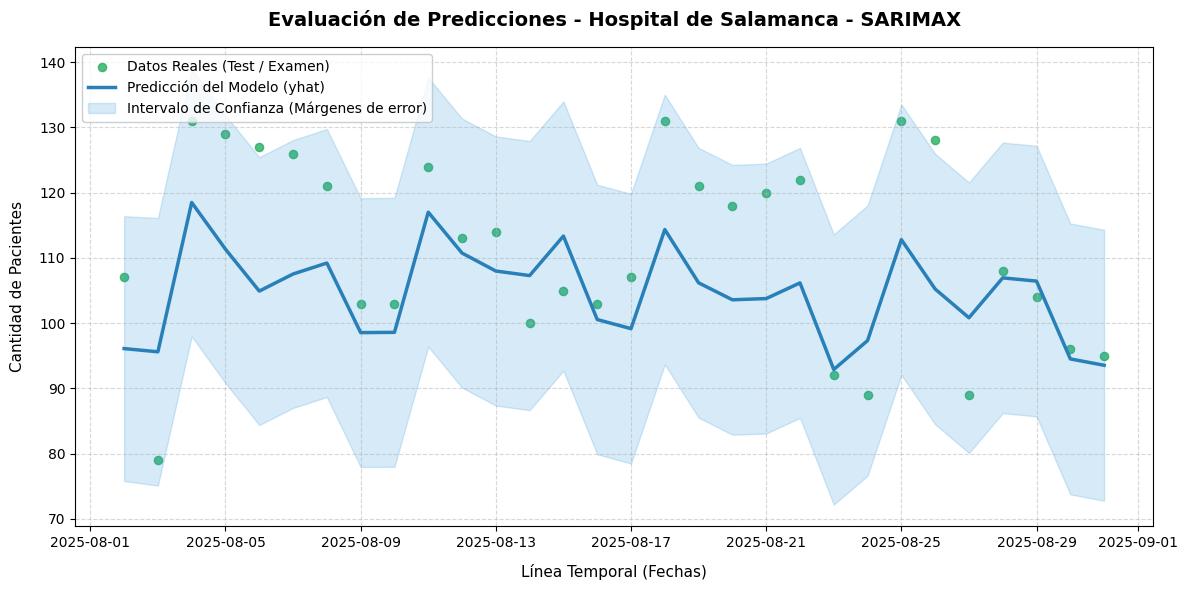

In [ ]:
plt.figure(figsize=(12, 6))

# 1. Puntos reales del test (Eje X: test_salamanca['ds'])
plt.scatter(test_salamanca['ds'], test_salamanca['y'],
            color='#27ae60', s=35, alpha=0.8, label='Datos Reales (Test / Examen)')

# 2. Línea de predicción
plt.plot(test_salamanca['ds'], prediccion_salamanca.predicted_mean.values,
         color='#2980b9', linewidth=2.5, label='Predicción del Modelo (yhat)')

# 3. Intervalos de confianza
intervalos = prediccion_salamanca.conf_int()
plt.fill_between(test_salamanca['ds'],
                 intervalos.iloc[:, 0].values,
                 intervalos.iloc[:, 1].values,
                 color='#3498db', alpha=0.2, label='Intervalo de Confianza (Márgenes de error)')

# Personalización de la gráfica
plt.title("Evaluación de Predicciones - Hospital de Salamanca - SARIMAX", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Línea Temporal (Fechas)", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Pacientes", fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#bdc3c7')

plt.tight_layout()
plt.show()

In [ ]:
tabla_comparativa['yhat_sarimax_segovia'] = prediccion_segovia.predicted_mean.values
tabla_comparativa['y_real_sarimax_segovia'] = test_segovia['y'].values
tabla_comparativa['error_absoluto_sarimax_segovia'] = (tabla_comparativa['y_real_sarimax_segovia'] - tabla_comparativa['yhat_sarimax_segovia']).abs()

print("--- COMPARATIVA DE PREDICCIONES PARA SARIMAX SEGOVIA ---")
columnas_ordenadas = [
    'y_real_prophet_salamanca', 'yhat_prophet_salamanca', 'error_absoluto_prophet_salamanca',
    'y_real_prophet_segovia', 'yhat_prophet_segovia', 'error_absoluto_prophet_segovia',
    'y_real_sarimax_salamanca', 'yhat_sarimax_salamanca', 'error_absoluto_sarimax_salamanca',
    'y_real_sarimax_segovia', 'yhat_sarimax_segovia', 'error_absoluto_sarimax_segovia'
]
print(tabla_comparativa[columnas_ordenadas].head())


error_medio = tabla_comparativa['error_absoluto_sarimax_segovia'].mean()

print("\n--- NOTA FINAL DEL MODELO ---")
print(f"De media, el modelo de sarimax segovia se equivoca en: {error_medio:.2f} pacientes por día.")

--- COMPARATIVA DE PREDICCIONES PARA SARIMAX SEGOVIA ---
   y_real_salamanca  yhat_salamanca  error_absoluto_salamanca  y_real_segovia  \
0               107       94.518866                 12.481134             103   
1                79       95.830717                 16.830717              86   
2               131      116.840983                 14.159017             100   
3               129      111.781879                 17.218121             149   
4               127      106.224019                 20.775981             110   

   yhat_segovia  error_absoluto_segovia  y_real_sarimax_salamanca  \
0     92.092238               10.907762                       107   
1     93.484738                7.484738                        79   
2    110.798536               10.798536                       131   
3    110.742597               38.257403                       129   
4    109.041218                0.958782                       127   

   yhat_sarimax_salamanca  error_absoluto

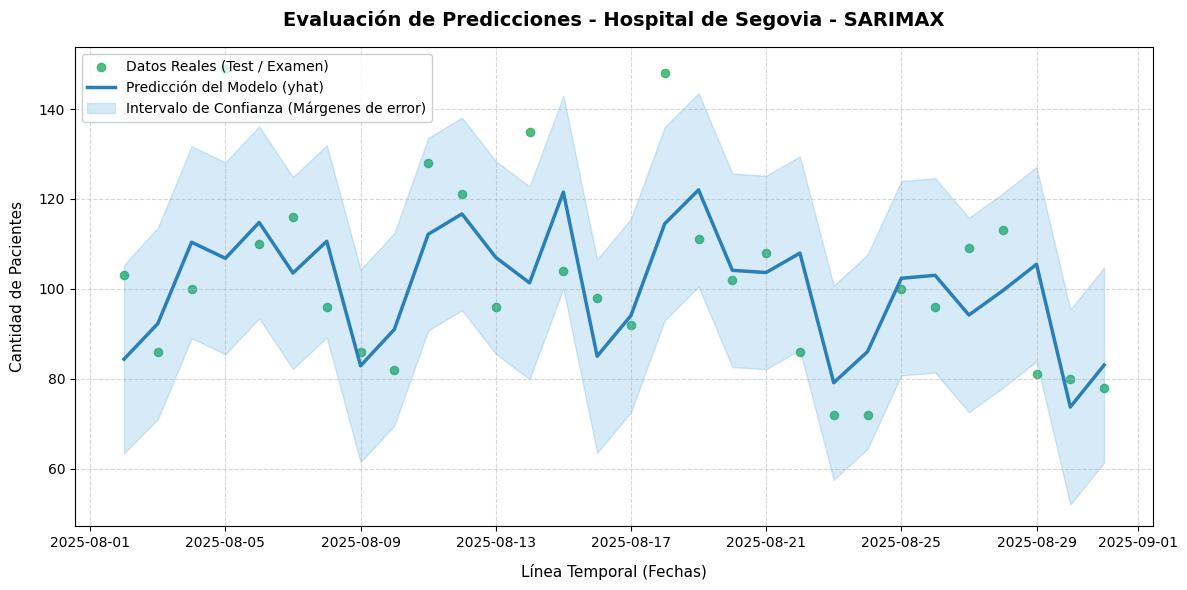

In [ ]:
plt.figure(figsize=(12, 6))

# 1. Puntos reales del test (Eje X: test_salamanca['ds'])
plt.scatter(test_segovia['ds'], test_segovia['y'],
            color='#27ae60', s=35, alpha=0.8, label='Datos Reales (Test / Examen)')

# 2. Línea de predicción
plt.plot(test_segovia['ds'], prediccion_segovia.predicted_mean.values,
         color='#2980b9', linewidth=2.5, label='Predicción del Modelo (yhat)')

# 3. Intervalos de confianza
intervalos = prediccion_segovia.conf_int()
plt.fill_between(test_segovia['ds'],
                 intervalos.iloc[:, 0].values,
                 intervalos.iloc[:, 1].values,
                 color='#3498db', alpha=0.2, label='Intervalo de Confianza (Márgenes de error)')

# Personalización de la gráfica
plt.title("Evaluación de Predicciones - Hospital de Segovia - SARIMAX", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Línea Temporal (Fechas)", fontsize=11, labelpad=10)
plt.ylabel("Cantidad de Pacientes", fontsize=11, labelpad=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#bdc3c7')

plt.tight_layout()
plt.show()

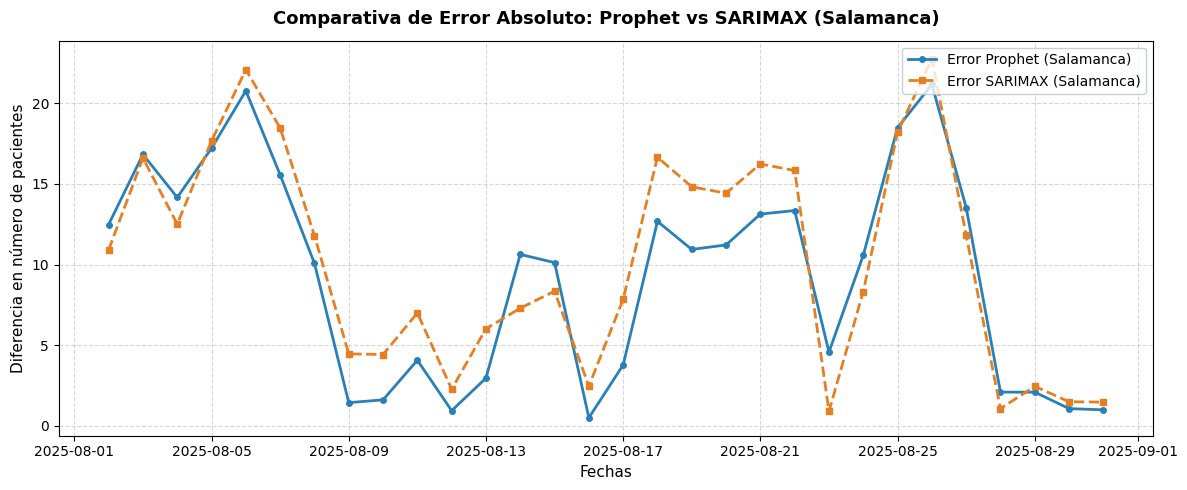

In [ ]:
#grafica comparativa de error absoluto de salamanca con ambos modelos
plt.figure(figsize=(12, 5))

# errores de Prophet
plt.plot(test_salamanca['ds'], tabla_comparativa['error_absoluto_prophet_salamanca'],
         color='#2980b9', linewidth=2, linestyle='-', marker='o', markersize=4,
         label='Error Prophet (Salamanca)')

# errores de SARIMAX
plt.plot(test_salamanca['ds'], tabla_comparativa['error_absoluto_sarimax_salamanca'],
         color='#e67e22', linewidth=2, linestyle='--', marker='s', markersize=4,
         label='Error SARIMAX (Salamanca)')

# configuracion y diseño
plt.title("Comparativa de Error Absoluto: Prophet vs SARIMAX (Salamanca)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Fechas", fontsize=11)
plt.ylabel("Diferencia en número de pacientes", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#bdc3c7')

plt.tight_layout()
plt.show()




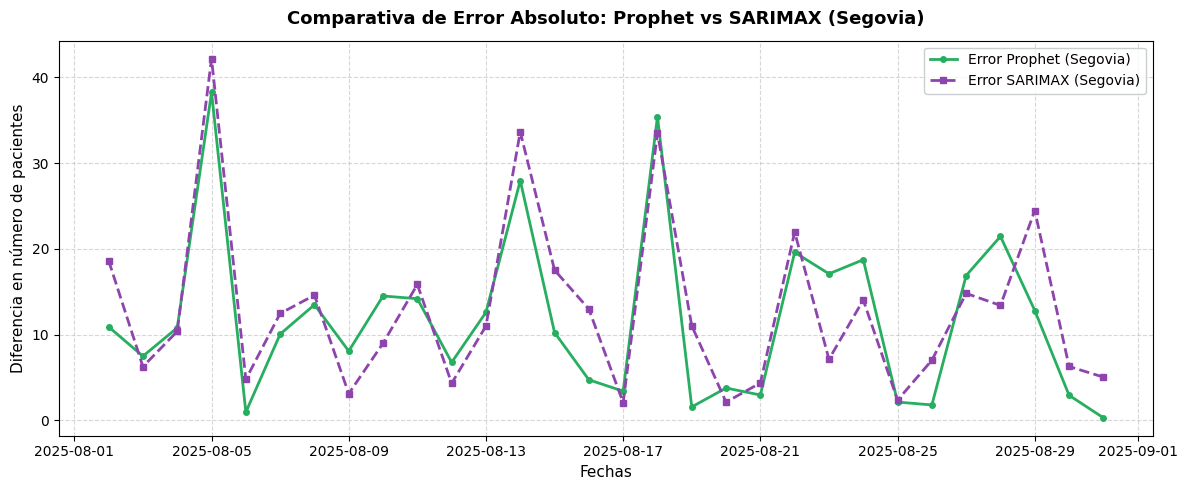

In [ ]:
#grafica comparativa de error absoluto de segovia con ambos modelos
plt.figure(figsize=(12, 5))

# errores de Prophet
plt.plot(test_segovia['ds'], tabla_comparativa['error_absoluto_prophet_segovia'],
         color='#27ae60', linewidth=2, linestyle='-', marker='o', markersize=4,
         label='Error Prophet (Segovia)')

# errores de SARIMAX
plt.plot(test_segovia['ds'], tabla_comparativa['error_absoluto_sarimax_segovia'],
         color='#8e44ad', linewidth=2, linestyle='--', marker='s', markersize=4,
         label='Error SARIMAX (Segovia)')

# configuracion y diseño
plt.title("Comparativa de Error Absoluto: Prophet vs SARIMAX (Segovia)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Fechas", fontsize=11)
plt.ylabel("Diferencia en número de pacientes", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#bdc3c7')

plt.tight_layout()
plt.show()